In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("✓ All imports successful!")

✓ All imports successful!


In [ ]:

# ALL FUNCTION DEFINITIONS


def load_and_explore_data(csv_path):
    """Load the AI4I 2020 dataset"""
    
    print("\n" + "="*70)
    print("[STEP 1] Loading Real Dataset from Kaggle")
    print("="*70)
    
    df = pd.read_csv(csv_path)
    
    print(f"\n✓ Dataset loaded successfully!")
    print(f"  • Total rows: {len(df)}")
    print(f"  • Total columns: {len(df.columns)}")
    
    print(f"\n✓ Machine Failure Distribution:")
    failure_counts = df['Machine failure'].value_counts()
    print(f"  • Normal (0): {failure_counts.get(0, 0)} machines")
    print(f"  • Failed (1): {failure_counts.get(1, 0)} machines")
    failure_rate = 100 * failure_counts.get(1, 0) / len(df)
    print(f"  • Failure rate: {failure_rate:.2f}%")
    
    return df

def prepare_data(df):
    """Select features and split into train/test"""
    
    print("\n" + "="*70)
    print("[STEP 2] Preparing Data")
    print("="*70)
    
    feature_columns = [
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]'
    ]
    
    X = df[feature_columns]
    y = df['Machine failure']
    
    print(f"\n✓ Features selected: {len(feature_columns)}")
    for i, col in enumerate(feature_columns, 1):
        print(f"  {i}. {col}")
    
    print(f"\n✓ Feature matrix shape: {X.shape}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"\n✓ Data split:")
    print(f"  • Training: {len(X_train)} samples (80%)")
    print(f"  • Testing: {len(X_test)} samples (20%)")
    
    return X_train, X_test, y_train, y_test, feature_columns

def train_model(X_train, y_train):
    """Train a Decision Tree classifier"""
    
    print("\n" + "="*70)
    print("[STEP 3] Training Decision Tree Classifier")
    print("="*70)
    
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    print(f"\n✓ Model trained successfully!")
    print(f"  • Tree depth: {model.get_depth()}")
    print(f"  • Number of nodes: {model.tree_.node_count}")
    
    return model

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Evaluate model performance"""
    
    print("\n" + "="*70)
    print("[STEP 4] Model Performance Evaluation")
    print("="*70)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    
    print(f"\n✓ Accuracy:")
    print(f"  • Training: {train_acc*100:.2f}%")
    print(f"  • Testing: {test_acc*100:.2f}%")
    
    print(f"\n✓ Precision: {precision*100:.2f}%")
    print(f"\n✓ Recall: {recall*100:.2f}%")
    
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"\n✓ Confusion Matrix:")
    print(f"  • True Negatives: {cm[0,0]}")
    print(f"  • False Positives: {cm[0,1]}")
    print(f"  • False Negatives: {cm[1,0]}")
    print(f"  • True Positives: {cm[1,1]}")
    
    return test_acc, precision, recall

def visualize_tree(model, feature_names):
    """Create decision tree visualization"""
    
    print("\n" + "="*70)
    print("[STEP 5] Visualizing Decision Tree")
    print("="*70)
    
    plt.figure(figsize=(20, 12))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=['Normal', 'Failure Risk'],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title('Decision Tree: Machine Maintenance Prediction Logic', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
    print(f"✓ Decision tree saved as: decision_tree.png")
    plt.show()

def demo_predictions(model, feature_names):
    """Show predictions on sample scenarios"""
    
    print("\n" + "="*70)
    print("[STEP 6] Live Demo - Sample Predictions")
    print("="*70)
    
    print("\n📍 Scenario 1: Normal Operating Machine")
    sample1 = pd.DataFrame([[298.1, 308.6, 1500, 45, 0]], columns=feature_names)
    pred1 = model.predict(sample1)[0]
    prob1 = model.predict_proba(sample1)[0]
    status1 = "✅ NORMAL" if pred1 == 0 else "⚠️ FAILURE RISK"
    print(f"  Prediction: {status1} ({max(prob1)*100:.1f}% confidence)")
    
    print("\n📍 Scenario 2: High Temperature + High Tool Wear")
    sample2 = pd.DataFrame([[310.5, 320.8, 1000, 60, 200]], columns=feature_names)
    pred2 = model.predict(sample2)[0]
    prob2 = model.predict_proba(sample2)[0]
    status2 = "✅ NORMAL" if pred2 == 0 else "⚠️ FAILURE RISK"
    print(f"  Prediction: {status2} ({max(prob2)*100:.1f}% confidence)")
    
    print("\n📍 Scenario 3: Medium Stress Levels")
    sample3 = pd.DataFrame([[304.2, 314.5, 1200, 50, 100]], columns=feature_names)
    pred3 = model.predict(sample3)[0]
    prob3 = model.predict_proba(sample3)[0]
    status3 = "✅ NORMAL" if pred3 == 0 else "⚠️ FAILURE RISK"
    print(f"  Prediction: {status3} ({max(prob3)*100:.1f}% confidence)")

print("✓ All functions defined successfully!")

✓ All functions defined successfully!


In [4]:
print("\n🚀 PREDICTIVE MACHINE MAINTENANCE CLASSIFIER")
print("="*70)

df = load_and_explore_data('../data/raw/ai4i2020.csv')


🚀 PREDICTIVE MACHINE MAINTENANCE CLASSIFIER

[STEP 1] Loading Real Dataset from Kaggle

✓ Dataset loaded successfully!
  • Total rows: 10000
  • Total columns: 14

✓ Machine Failure Distribution:
  • Normal (0): 9661 machines
  • Failed (1): 339 machines
  • Failure rate: 3.39%


In [ ]:

# DATA QUALITY CHECK


print("\n" + "="*70)
print("[STEP 1.5] Data Quality Check")
print("="*70)

print(f"\n✓ Missing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print(f"  • No missing values ✓ (Dataset is clean)")
else:
    print(missing)

print(f"\n✓ Dataset shape: {df.shape}")
print(f"✓ Data types:")
print(df.dtypes)

print(f"\n✓ First few rows:")
print(df.head())


[STEP 1.5] Data Quality Check

✓ Missing values:
  • No missing values ✓ (Dataset is clean)

✓ Dataset shape: (10000, 14)
✓ Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

✓ First few rows:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2         

In [7]:
X_train, X_test, y_train, y_test, feature_cols = prepare_data(df)


[STEP 2] Preparing Data

✓ Features selected: 5
  1. Air temperature [K]
  2. Process temperature [K]
  3. Rotational speed [rpm]
  4. Torque [Nm]
  5. Tool wear [min]

✓ Feature matrix shape: (10000, 5)

✓ Data split:
  • Training: 8000 samples (80%)
  • Testing: 2000 samples (20%)


In [8]:
model = train_model(X_train, y_train)


[STEP 3] Training Decision Tree Classifier

✓ Model trained successfully!
  • Tree depth: 5
  • Number of nodes: 25


In [9]:
acc, prec, rec = evaluate_model(model, X_train, X_test, y_train, y_test)


[STEP 4] Model Performance Evaluation

✓ Accuracy:
  • Training: 97.78%
  • Testing: 97.85%

✓ Precision: 75.00%

✓ Recall: 44.26%

✓ Confusion Matrix:
  • True Negatives: 1930
  • False Positives: 9
  • False Negatives: 34
  • True Positives: 27



[STEP 5] Visualizing Decision Tree
✓ Decision tree saved as: decision_tree.png


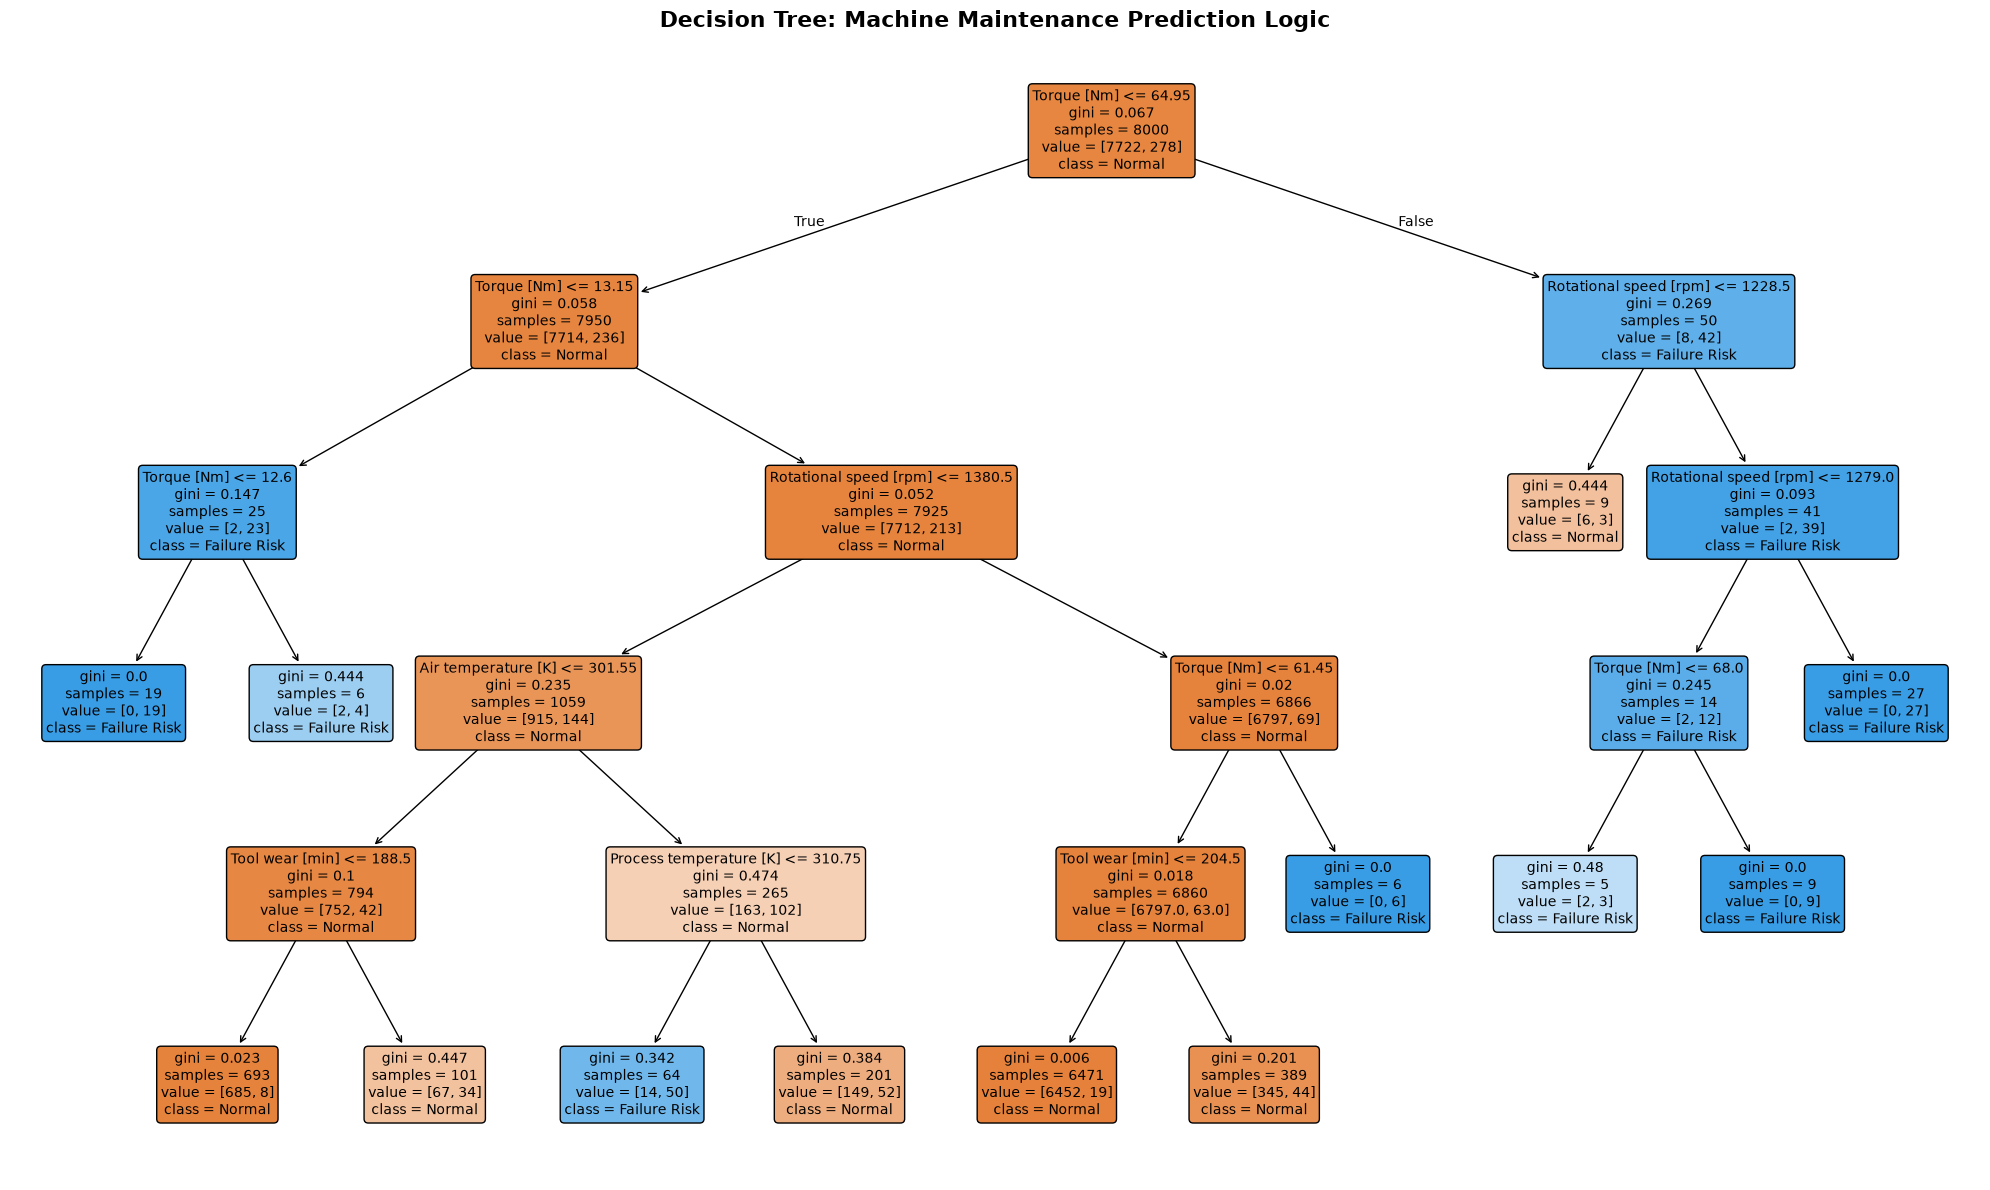

In [10]:
visualize_tree(model, feature_cols)

In [11]:
demo_predictions(model, feature_cols)


[STEP 6] Live Demo - Sample Predictions

📍 Scenario 1: Normal Operating Machine
  Prediction: ✅ NORMAL (99.7% confidence)

📍 Scenario 2: High Temperature + High Tool Wear
  Prediction: ✅ NORMAL (74.1% confidence)

📍 Scenario 3: Medium Stress Levels
  Prediction: ✅ NORMAL (74.1% confidence)
